In [3]:
!pip install tensorflow


In [8]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense


In [9]:
model = Sequential([
    Input(shape=(10,)),
    Dense(10,activation='relu'),
    Dense(21,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │           231 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363 (1.42 KB)

 Trainable params: 363 (1.42 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics=['accuracy']
)

# Whole code

In [20]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [21]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [22]:
# ============================================================
# 3. SPLIT DATA INTO TRAINING AND TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)



X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


In [23]:
# ============================================================
# 4. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# ============================================================
# 5. BUILD SEQUENTIAL MODEL
# ============================================================

model = Sequential([
    
    Input(shape=(30,)),
    
    Dense(32, activation="relu"),
    
    Dense(16, activation="relu"),
    
    Dense(1, activation="sigmoid")
])

In [25]:
# ============================================================
# 6. DISPLAY MODEL STRUCTURE
# ============================================================

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ============================================================
# 7. COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
# ============================================================
# 8. MODEL CHECKPOINT
# ============================================================

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)


In [28]:
# ============================================================
# 9. EARLY STOPPING
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [29]:
# ============================================================
# 10. TRAIN MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping]
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8132 - loss: 0.5787 - val_accuracy: 0.8791 - val_loss: 0.5040
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9066 - loss: 0.4177 - val_accuracy: 0.9451 - val_loss: 0.3736
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9368 - loss: 0.3085 - val_accuracy: 0.9451 - val_loss: 0.2821
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9560 - loss: 0.2323 - val_accuracy: 0.9560 - val_loss: 0.2203
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9560 - loss: 0.1854 - val_accuracy: 0.9560 - val_loss: 0.1775
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9643 - loss: 0.1527 - val_accuracy: 0.9560 - val_loss: 0.1470
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9698 - loss: 0.1289 - val_accuracy: 0.9670 - val_loss: 0.1259
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9725 - loss: 0.1130 - val_accuracy: 0.9780 - v

In [30]:
# ============================================================
# 11. EVALUATE MODEL
# ============================================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9561 - loss: 0.1043

Test Loss: 0.10433556884527206
Test Accuracy: 0.9561403393745422


In [31]:
# ============================================================
# 12. MAKE PREDICTIONS
# ============================================================

predictions = model.predict(X_test)

print("\nRaw predictions:")
print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Raw predictions:
[[6.1621103e-10]
 [9.9999946e-01]
 [6.6007063e-04]
 [2.7943280e-01]
 [8.0282614e-11]
 [9.9824858e-01]
 [9.9999523e-01]
 [7.3773371e-08]
 [1.6392047e-06]
 [2.1624480e-14]]


In [32]:
# ============================================================
# 13. CONVERT PROBABILITIES INTO 0/1 CLASSES
# ============================================================

y_pred = (predictions >= 0.5).astype(int)

print("\nPredicted classes:")
print(y_pred[:10])


Predicted classes:
[[0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]]


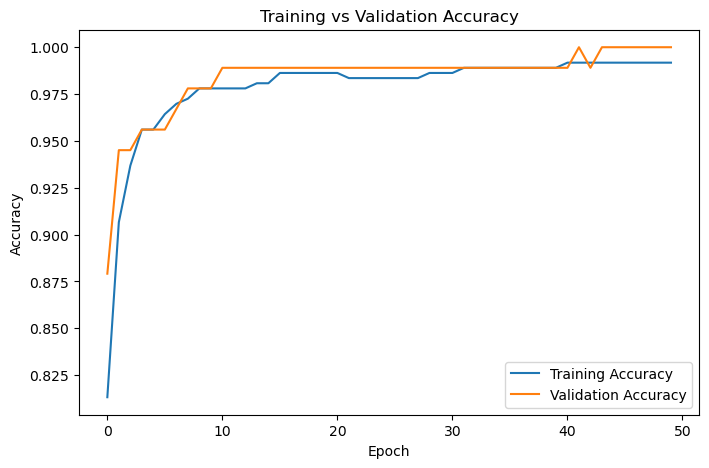

In [33]:
# ============================================================
# 14. VISUALIZE TRAINING & VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

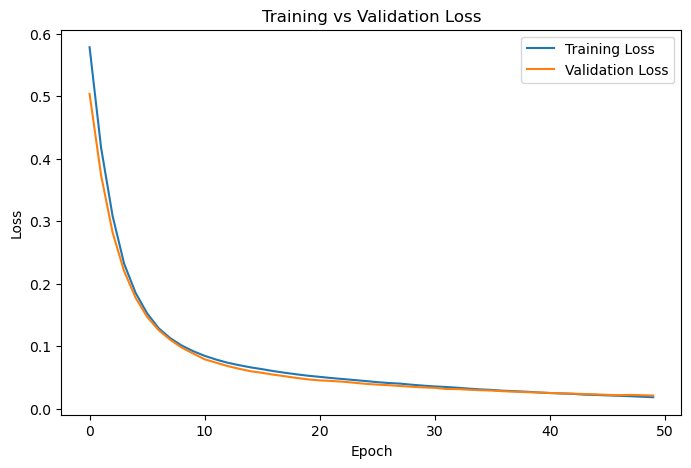

In [34]:
# ============================================================
# 15. VISUALIZE TRAINING & VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()


In [35]:
# ============================================================
# 16. SAVE FINAL MODEL
# ============================================================

model.save("breast_cancer_ann.keras")

print("\nModel saved successfully!")


Model saved successfully!
